In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [79]:
# Load cali housing data
housing = fetch_california_housing()

X = housing.data
y = housing.target

print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [80]:
# Convert to datafram for easy analysis
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["HouseValue"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [81]:
df.info()

print("="*50)
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


No null values, no need to drop/impute any features.

In [82]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # 20% of data to test set
    random_state=1
)

Since this is a regression based task, linear regression and decision tree would be good candidate models for this.

In [83]:
# Instantiate models
lr = LinearRegression()

lr.fit(X_train, y_train) # Fit on training data 

# Show coefficients
coefficients = pd.DataFrame({
    "Feature": housing.feature_names,
    "Coefficient": lr.coef_
})

y_pred_lr = lr.predict(X_test)  # Predict on test data

coefficients

,Feature,Coefficient
0,MedInc,0.438565
1,HouseAge,0.009687
2,AveRooms,-0.104705
3,AveBedrms,0.632189
4,Population,-0.000004
5,AveOccup,-0.003448
6,Latitude,-0.425964
7,Longitude,-0.440601


In [ ]:
# Evaluate model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

MSE: 0.5291402345397401
RMSE: 0.7274202599183914
R²: 0.5965968374812283


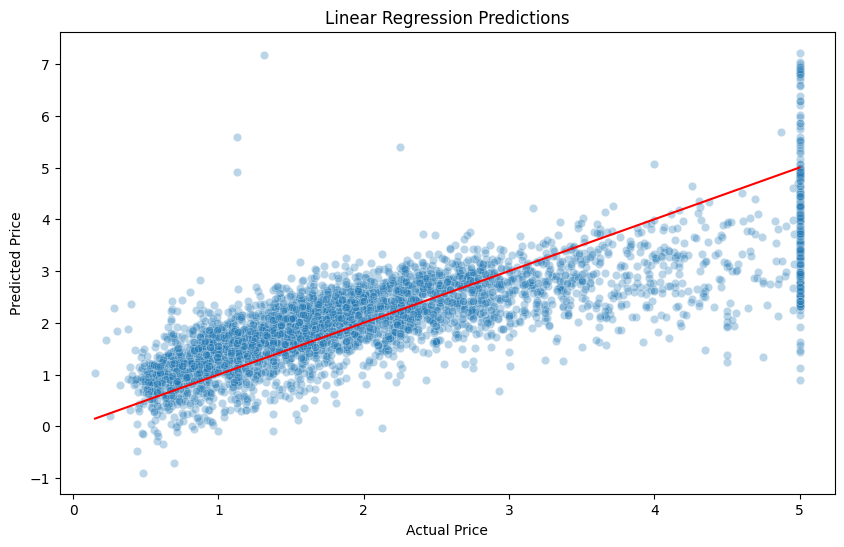

In [85]:
# Plot results
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_lr,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression Predictions")

plt.show()

In [86]:
# Instantiate model
dt = DecisionTreeRegressor(random_state=1)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [89]:
# Predict house prices on the test set
y_pred_dt = dt.predict(X_test)

# Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)

print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R²:", r2_dt)

MSE: 0.494650217072529
RMSE: 0.7033137401420002
R²: 0.6228911564791075


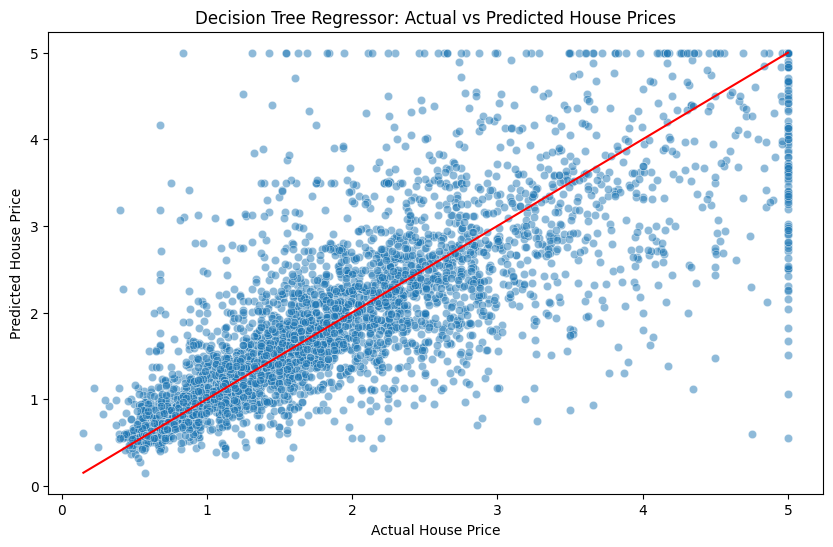

In [88]:
# Plot results
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_dt,
    alpha=0.5
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="solid"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Decision Tree Regressor: Actual vs Predicted House Prices")

plt.show()

In this assignment, I used Linear Regression and Decision Tree Regression to predict California housing prices. Linear Regression learned a linear relationship between the housing features and the target variable, while Decision Tree Regression learned a set of decision rules that could capture more complex patterns in the data. After evaluating both models, the Decision Tree Regressor achieved better performance with a lower MSE (0.495 vs 0.529), lower RMSE (0.703 vs 0.727), and higher R² score (0.623 vs 0.597). This indicates that the Decision Tree was able to explain more variation in housing prices and make more accurate predictions. Through this assignment, I learned the Scikit-Learn workflow of loading data, splitting into training and testing sets, training models with fit(), generating predictions with predict(), and evaluating model performance using regression metrics and visualizations.

In this assignment, I used the Linear Regression and Decision Tree Regression models to predict the housing prices. The Linear Regression model learned a linear relationship between the features and target variables, while the Decision Tree Regressor learned from splits that captured that modeled non-linear patterns more effectively.

After evaluating both models, the Decision Tree Regressor achieved better performance with a lower MSE (0.495 vs 0.529), lower RMSE (0.703 vs 0.727), and higher R² score (0.623 vs 0.597).